In [1]:
import healpy as hp
import glob
from ligo.skymap.io import read_sky_map
import numpy as np
import os

# Create output directory
output_dir = '/Users/leo/Desktop/gw-hands-on-school-2025/LVK_skyloc_samples/GWTC4p0_galactic_skymaps'
os.makedirs(output_dir, exist_ok=True)

skymap_files_equatorial = glob.glob('/Users/leo/Desktop/gw-hands-on-school-2025/LVK_skyloc_samples/GWTC4p0_skymaps/*Mixed_*.fits')

for skymap_nr, skymap_file in enumerate(skymap_files_equatorial):
    print(f"Processing {skymap_nr+1}/{len(skymap_files_equatorial)}: {os.path.basename(skymap_file)}")
    
    # Read the skymap
    skymap, header = read_sky_map(skymap_file, distances=False, moc=False)
    
    nside = hp.get_nside(skymap)
    ordering = 'nested' if header.get('ORDERING') == 'NESTED' else 'ring'
    
    # If not in RING ordering, convert to RING for rotation
    if ordering == 'nested':
        skymap = hp.reorder(skymap, n2r=True)  # NESTED to RING
    
    # Convert to spherical harmonics
    lmax = 3 * nside - 1  # Standard choice
    alm = hp.map2alm(skymap, lmax=lmax)
    
    # Create rotator and rotate alms
    r = hp.Rotator(coord=['C', 'G'])
    alm_rotated = r.rotate_alm(alm)
    
    # Convert back to map
    skymap_gal = hp.alm2map(alm_rotated, nside=nside, verbose=False)
    
    # Convert back to original
    if ordering == 'nested':
        skymap_gal = hp.reorder(skymap_gal, r2n=True)  # RING to NESTED
    
    # Normalize
    skymap_gal = skymap_gal / np.sum(skymap_gal)
    
    # Save
    output_file = os.path.join(output_dir, f'mixed_galactic_{skymap_nr}.fits')
    hp.write_map(output_file, skymap_gal,
                 coord='G',
                 nest=(ordering == 'nested'),
                 overwrite=True)

print("Coordinate transformation complete!")

/opt/homebrew/Caskroom/miniconda/base/envs/gw-school-2025/lib/python3.11/site-packages/igwn_ligolw/lsctables.py:57: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


Processing 1/85: IGWN-GWTC4p0-1a206db3d_721-GW230911_195324-Mixed_Skymap_PEDataRelease.fits


/var/folders/f2/1x87b6ls4fl58x7zv4z2nqfw0000gn/T/ipykernel_33686/2972620778.py:35: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  skymap_gal = hp.alm2map(alm_rotated, nside=nside, verbose=False)
setting the output map dtype to [dtype('float64')]
/var/folders/f2/1x87b6ls4fl58x7zv4z2nqfw0000gn/T/ipykernel_33686/2972620778.py:35: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  skymap_gal = hp.alm2map(alm_rotated, nside=nside, verbose=False)
setting the output map dtype to [dtype('float64')]


Processing 2/85: IGWN-GWTC4p0-1a206db3d_721-GW231230_170116-Mixed_Skymap_PEDataRelease.fits
Processing 3/85: IGWN-GWTC4p0-1a206db3d_721-GW230824_033047-Mixed_Skymap_PEDataRelease.fits


/var/folders/f2/1x87b6ls4fl58x7zv4z2nqfw0000gn/T/ipykernel_33686/2972620778.py:35: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  skymap_gal = hp.alm2map(alm_rotated, nside=nside, verbose=False)
setting the output map dtype to [dtype('float64')]


...

Processing 83/85: IGWN-GWTC4p0-1a206db3d_721-GW230928_215827-Mixed_Skymap_PEDataRelease.fits


/var/folders/f2/1x87b6ls4fl58x7zv4z2nqfw0000gn/T/ipykernel_33686/2972620778.py:35: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  skymap_gal = hp.alm2map(alm_rotated, nside=nside, verbose=False)
setting the output map dtype to [dtype('float64')]
/var/folders/f2/1x87b6ls4fl58x7zv4z2nqfw0000gn/T/ipykernel_33686/2972620778.py:35: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  skymap_gal = hp.alm2map(alm_rotated, nside=nside, verbose=False)
setting the output map dtype to [dtype('float64')]


Processing 84/85: IGWN-GWTC4p0-1a206db3d_721-GW230704_212616-Mixed_Skymap_PEDataRelease.fits
Processing 85/85: IGWN-GWTC4p0-1a206db3d_721-GW230630_125806-Mixed_Skymap_PEDataRelease.fits


/var/folders/f2/1x87b6ls4fl58x7zv4z2nqfw0000gn/T/ipykernel_33686/2972620778.py:35: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  skymap_gal = hp.alm2map(alm_rotated, nside=nside, verbose=False)
setting the output map dtype to [dtype('float64')]


Coordinate transformation complete!


Found 85 skymap files


/var/folders/f2/1x87b6ls4fl58x7zv4z2nqfw0000gn/T/ipykernel_33686/1367640775.py:32: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  skymap = hp.read_map(fits_file, verbose=False)


Processed 10/85 files
Processed 20/85 files
Processed 30/85 files
Processed 40/85 files
Processed 50/85 files
Processed 60/85 files
Processed 70/85 files
Processed 80/85 files


/var/folders/f2/1x87b6ls4fl58x7zv4z2nqfw0000gn/T/ipykernel_33686/1367640775.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


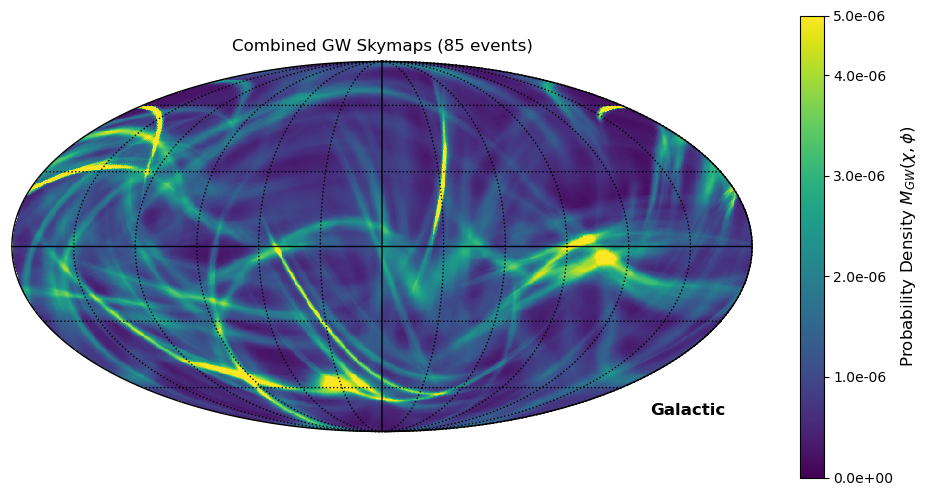

In [ ]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
import glob


#skymap_files = glob.glob("/Users/leo/Desktop/gw-hands-on-school-2025/LVK_skyloc_samples/GWTC_skymaps/*Mixed*.fits")

#skymap_files_2p1 = glob.glob("/Users/leo/Desktop/gw-hands-on-school-2025/LVK_skyloc_samples/GWTC2p1_skymaps/*Mixed.fits")
#skymap_files_3p0 = glob.glob("/Users/leo/Desktop/gw-hands-on-school-2025/LVK_skyloc_samples/GWTC3p0_skymaps/*Mixed.fits")
skymap_files_4p0 = glob.glob("/Users/leo/Desktop/gw-hands-on-school-2025/LVK_skyloc_samples/GWTC4p0_galactic_skymaps/*mixed_*.fits")

skymap_files = skymap_files_4p0 #+ skymap_files_2p1 + skymap_files_3p0 

# Get all .fits files in directory
    
if not skymap_files:
    print(f"No .fits files found")
    
print(f"Found {len(skymap_files)} skymap files")
    
NSIDE = 256
NPIX = hp.nside2npix(NSIDE)
    
    # Define the combined (added) skymap
combined_map = np.zeros(NPIX)
    
    # Process the skymaps
for i, fits_file in enumerate(skymap_files):
    try:
        # Read skymap
        skymap = hp.read_map(fits_file, verbose=False)
       
            
        # Resample to common resolution(important with power=-2)
        skymap_resized = hp.ud_grade(skymap, NSIDE, power=-2)
        
        # Add to combined map
        combined_map += skymap_resized / np.sum(skymap_resized)  # Normalize each map before adding, so that each contributes equally
            
        if (i+1) % 10 == 0:
            print(f"Processed {i+1}/{len(skymap_files)} files")
                
    except Exception as e:
        print(f"Error reading {fits_file}: {e}")
        continue
    

combined_map = combined_map / np.sum(combined_map)  # Normalize combined map

    
# Plot the combined skymap
plt.figure(figsize=(12, 6))
    
hp.mollview(
    combined_map,
    title=f"Combined GW Skymaps ({len(skymap_files)} events)",
    min=0,
    max=np.percentile(combined_map[combined_map > 0], 99),
    cbar=False,
    cmap='viridis',
    format='%.1e',
    coord='G',
    unit="Probability Density $M_{GW}(\chi,\phi)$", 
    hold=True,
    return_projected_map=True
    )
    
hp.graticule()

ax = plt.gca()
im = ax.get_images()[0]
cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.05, format='%.1e')
cbar.set_label('Probability Density $M_{GW}(\chi,\phi)$', fontsize=12)
plt.tight_layout()
plt.savefig('observed_combined_galactic_skymap.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()